# Méthodes d'affichage des représentations internes sans DeconvNet

CNAM certification pro IA - RCP 209 - Semestre 1 2024/2025 - Nicolas Guillard

Projet basé sur l'article "Zeiler and al. 2013". Ce carnet accompagne le rapport.

<a href="https://creativecommons.org/licenses/by-nc-sa/4.0/?ref=chooser-v1" target="_blank" rel="license noopener noreferrer" style="display:inline-block;">CC BY-NC-SA 4.0<img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/cc.svg?ref=chooser-v1" alt=""><img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/by.svg?ref=chooser-v1" alt=""><img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/nc.svg?ref=chooser-v1" alt=""><img style="height:22px!important;margin-left:3px;vertical-align:text-bottom;" src="https://mirrors.creativecommons.org/presskit/icons/sa.svg?ref=chooser-v1" alt=""></a>

Parmi les méthodes d'affichage des représentations internes, DeconvNet n'est pas utilisé dans ce carnet. A la place on affichera des filtres (noyaux) de convolution et des couches cachées.

## Eléments préparatoires

### Modules

In [1]:
import os
from typing import Tuple
import torch
import torchvision
from torchvision.io import decode_image
from PIL import Image

from torchinfo import summary

In [2]:
from utils.convnet_wrapper_for_deconvolution import ConvnetWrapperForDeconvolution
from utils.utils_images import display_image_tensor as display_image_tensor_, display_images_tensor_grid, i_suffix_fr, to_0_1

### Utilitaire(s)

Fonction d'afficage d'une image au format `torch.Tensor`.

In [3]:
# Spécifiquement pour un carnet de type Jupyter
def display_image_tensor(
        img_tensor, resize: Tuple[int, int] = None, resample: int = Image.Resampling.NEAREST, verbose=True
        ):
    if display:
        display_image_tensor_(img_tensor, resize=resize, resample=resample, verbose=verbose, fn_display=display)

### Chargement des modèles

#### AlexNet

Chargement du modèle AlexNet pré-entraîné sur ImageNet, et affichage de ses couches.

In [4]:
model_convnet_alexnet = torch.hub.load('pytorch/vision', "alexnet", weights=torchvision.models.AlexNet_Weights.IMAGENET1K_V1)
model_convnet_alexnet.eval()
print(model_convnet_alexnet)

model_for_deconv_alexnet = ConvnetWrapperForDeconvolution(model_convnet_alexnet, model_convnet_alexnet.features)
model_for_deconv_alexnet.set_return_switch_indices(False)

Using cache found in /Users/me/.cache/torch/hub/pytorch_vision_main


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Affichage des dimensions des couches cachées

In [5]:
summary(model_convnet_alexnet, input_size=torch.Size([1, 3, 224, 224]), mode="eval")

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 1000]                 --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 64, 55, 55]           23,296
│    └─ReLU: 2-2                         [1, 64, 55, 55]           --
│    └─MaxPool2d: 2-3                    [1, 64, 27, 27]           --
│    └─Conv2d: 2-4                       [1, 192, 27, 27]          307,392
│    └─ReLU: 2-5                         [1, 192, 27, 27]          --
│    └─MaxPool2d: 2-6                    [1, 192, 13, 13]          --
│    └─Conv2d: 2-7                       [1, 384, 13, 13]          663,936
│    └─ReLU: 2-8                         [1, 384, 13, 13]          --
│    └─Conv2d: 2-9                       [1, 256, 13, 13]          884,992
│    └─ReLU: 2-10                        [1, 256, 13, 13]          --
│    └─Conv2d: 2-11                      [1, 256, 13, 13]         

#### VGG16

Chargement du modèle VGG16 pré-entraîné sur ImageNet, et affichage de ses couches.


In [6]:
model_convnet_vgg16 = torch.hub.load('pytorch/vision', "vgg16", weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
model_convnet_vgg16.eval()
print(model_convnet_vgg16)

model_for_deconv_vgg16 = ConvnetWrapperForDeconvolution(model_convnet_vgg16, model_convnet_vgg16.features)
model_for_deconv_vgg16.set_return_switch_indices(False)

Using cache found in /Users/me/.cache/torch/hub/pytorch_vision_main


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Affichage des dimensions des couches cachées

In [7]:
summary(model_convnet_vgg16, input_size=torch.Size([1, 3, 224, 224]), mode="eval")

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

### Données

Utilisation des transformations de prétraitement des images respectivement pour les modèles AlexNet et VGG16. Ces transformations sont appliquées à l'image d'entrée avant de l'envoyer au modèle.

In [8]:
transforms_for_alexnet = torchvision.models.AlexNet_Weights.IMAGENET1K_V1.transforms()
transforms_for_vgg16 = torchvision.models.VGG16_Weights.IMAGENET1K_V1.transforms()

Image utilisée appartenant au je de validation de la base de données ImageNet.

Dimensions : torch.Size([3, 500, 333]) 	Valeur min : 0 	Valeur max : 255


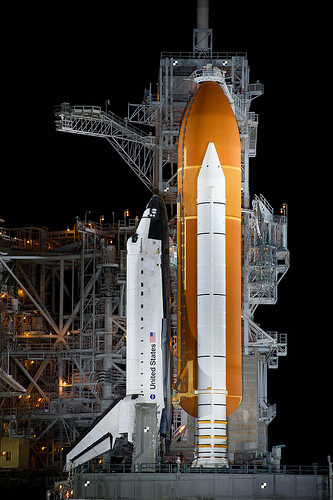

In [9]:
image_path = "."  # Replace with your image path
image_filename = "ILSVRC2012_val_00000559.JPEG" # navette spatiale
#image_filename = "ILSVRC2012_val_00023707.JPEG" # Tête de caméléon
img = decode_image(os.path.join(image_path, image_filename), mode="RGB")
display_image_tensor(img)

## Affichage des filtres (noyaux) de convolution

### De la première couche de convolution d'un ConvNet

#### AlexNet

Visualisation des 64 filtres du module de convolution `features[0]` du modèle AlexNet. Ces filtres sont de taille 3x11x11, soit 3 filtes de taille 11x11. Ils sont affichés en couleur, et permettent une visualisation de la manière dont le modèle AlexNet traite les images d'entrée. Ces filtres sont les premiers à être appliqués, et ils permettent de détecter des motifs simples tels que des bords, des textures simples ou des couleurs.

Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
torch.Size([64, 3, 11, 11])


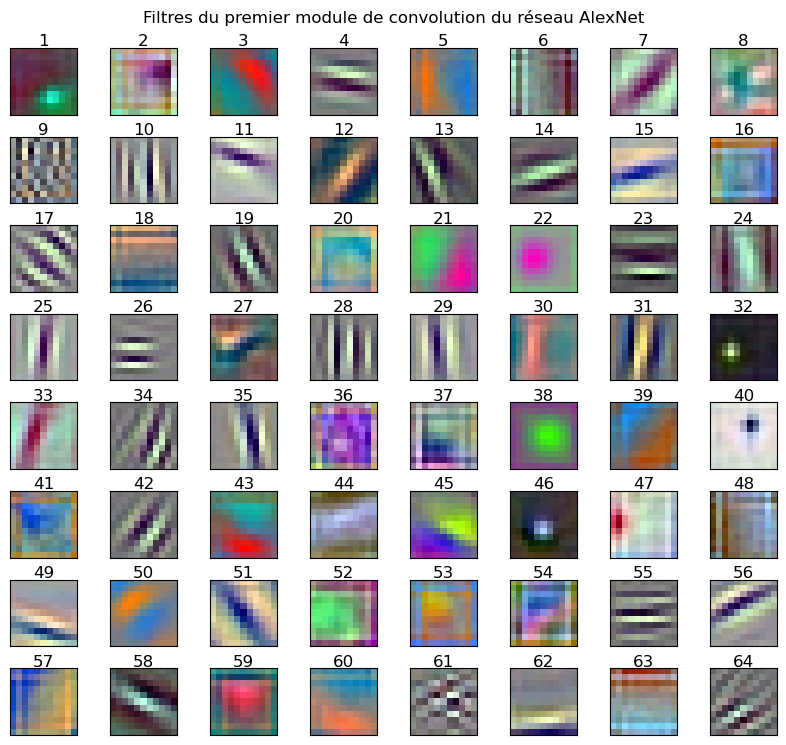

In [10]:
i_module = 0
module = model_convnet_alexnet.features[i_module]
print(module)
filters = module.weight.clone().detach().clone()
print(filters.size())

# Normalization to [0..1], like a RGB picture
for i in range(filters.size(0)):
    filters[i] = (filters[i] - filters[i].min()) / (filters[i].max() - filters[i].min())

per_rows = 8
titles=list(range(1, filters.size(0) + 1))
display_images_tensor_grid(
    filters,
    per_rows=per_rows,
    suptitle="Filtres du premier module de convolution du réseau AlexNet", titles=titles,
    figsize=(8, 8)
    )

#### VGG16

Visualisation des 64 filtres du module de convolution `features[0]` du modèle VGG16. Ces filtres sont de taille 3x11x11, soit 3 filtes de taille 11x11. Ils sont affichés en couleur, et permettent une visualisation de la manière dont le modèle VGG16 traite les images d'entrée. Ils sont beaucoup moins interprétables que ceux d'AlexNet, du fait de leur petite taille.

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([64, 3, 3, 3])


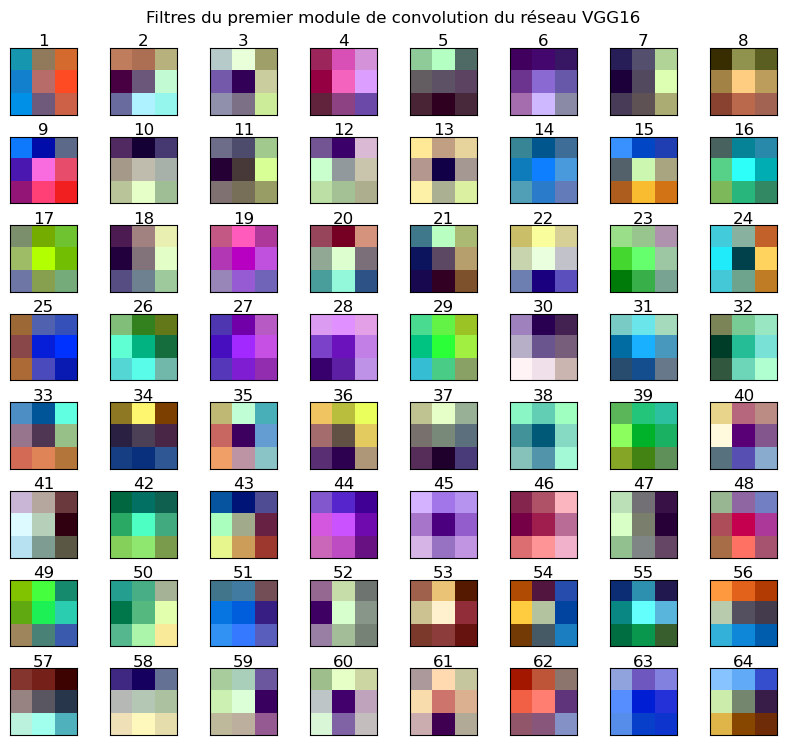

In [11]:
i_module = 0
module = model_convnet_vgg16.features[i_module]
print(module)
filters = module.weight.clone().detach().clone()
print(filters.size())

# Normalization to [0..1], like a RGB picture
for i in range(filters.size(0)):
    filters[i] = (filters[i] - filters[i].min()) / (filters[i].max() - filters[i].min())

per_rows = 8
titles=list(range(1, filters.size(0) + 1))
display_images_tensor_grid(
    filters,
    per_rows=per_rows,
    suptitle="Filtres du premier module de convolution du réseau VGG16",
    titles=titles,
    figsize=(8, 8)
    )

### D'une autre couche plus profonde

#### AlexNet

Visualisation des quelques filtres du module de convolution `features[6]` du modèle AlexNet, parmi les 384 appris, chacun d'une taille de 192x3x3, c'est-à-dire composés de 192 strates de taille 3x3.

Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([384, 192, 3, 3])


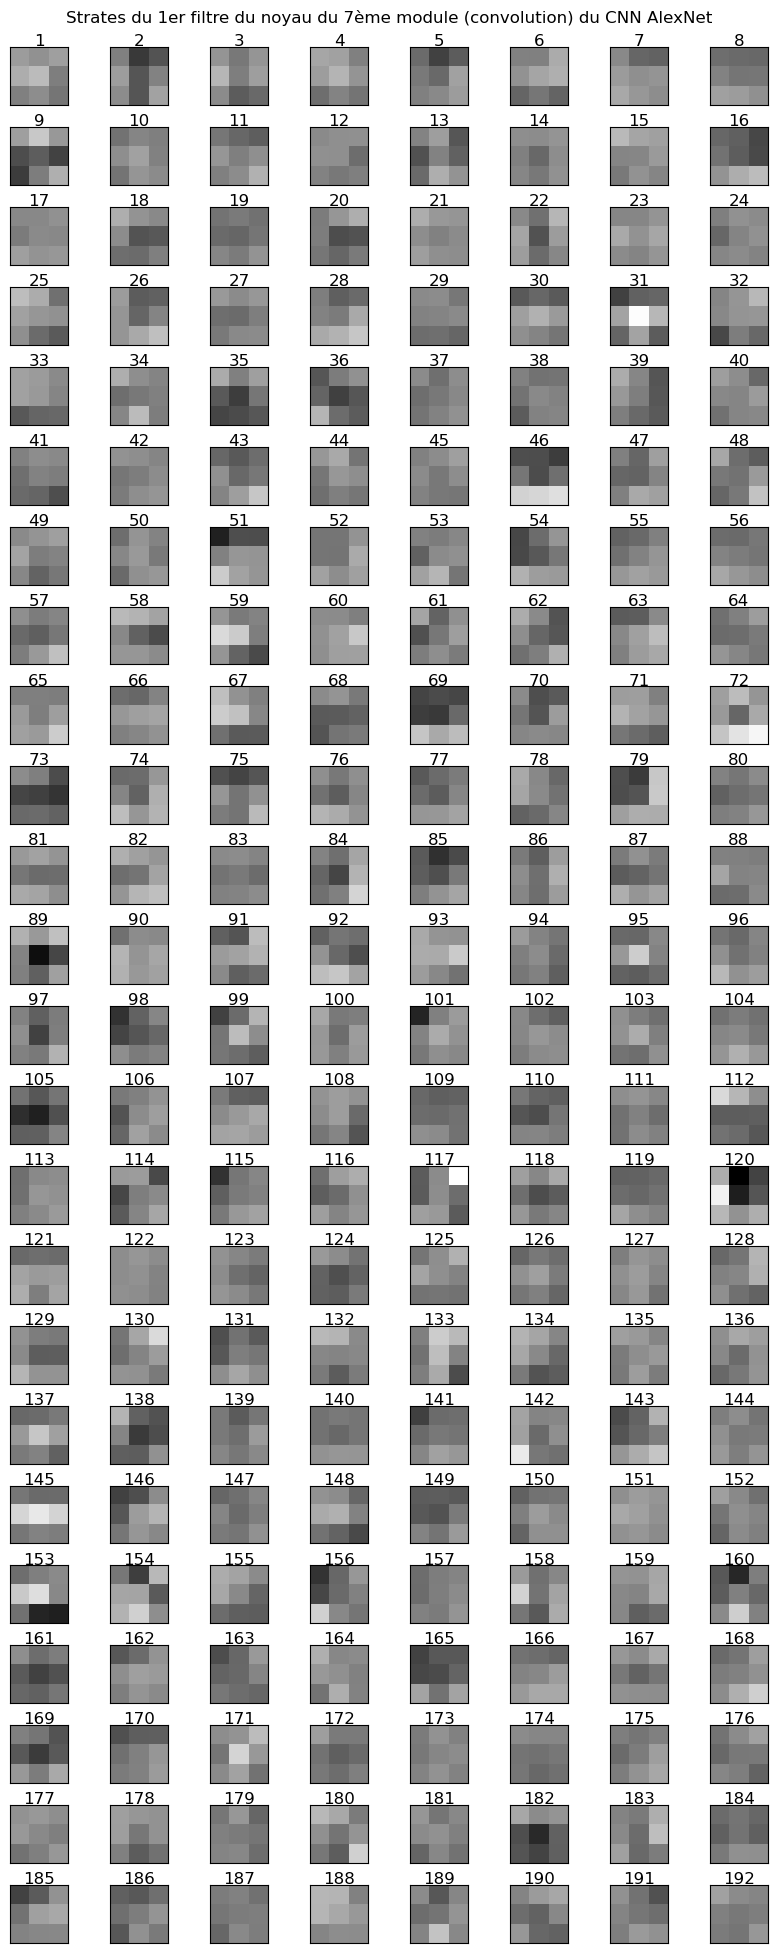

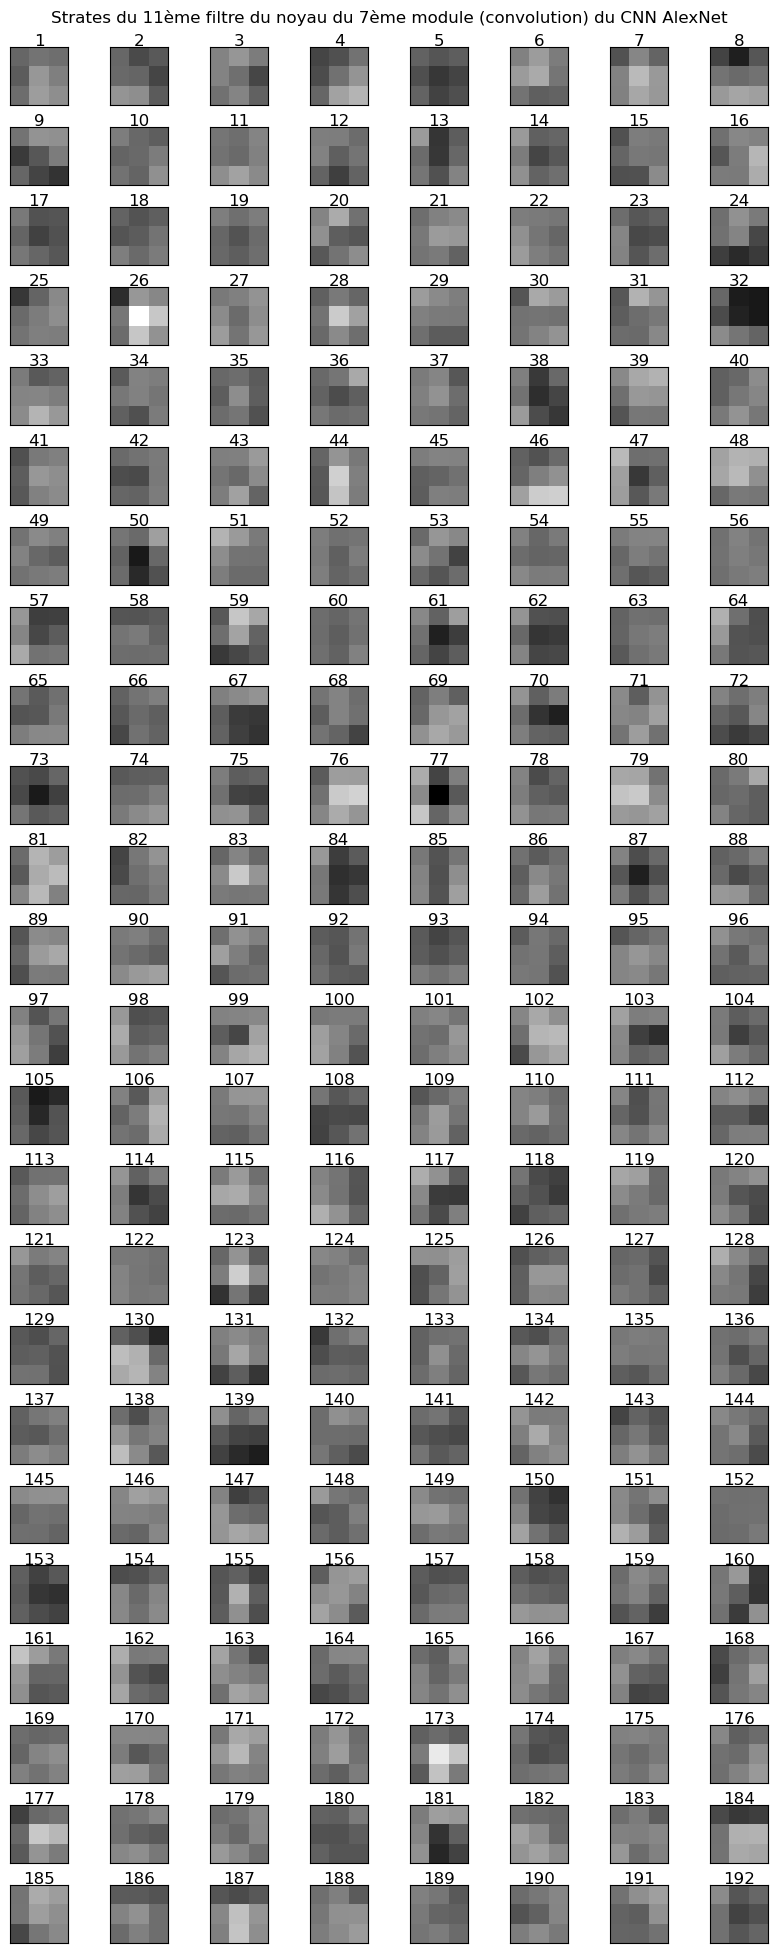

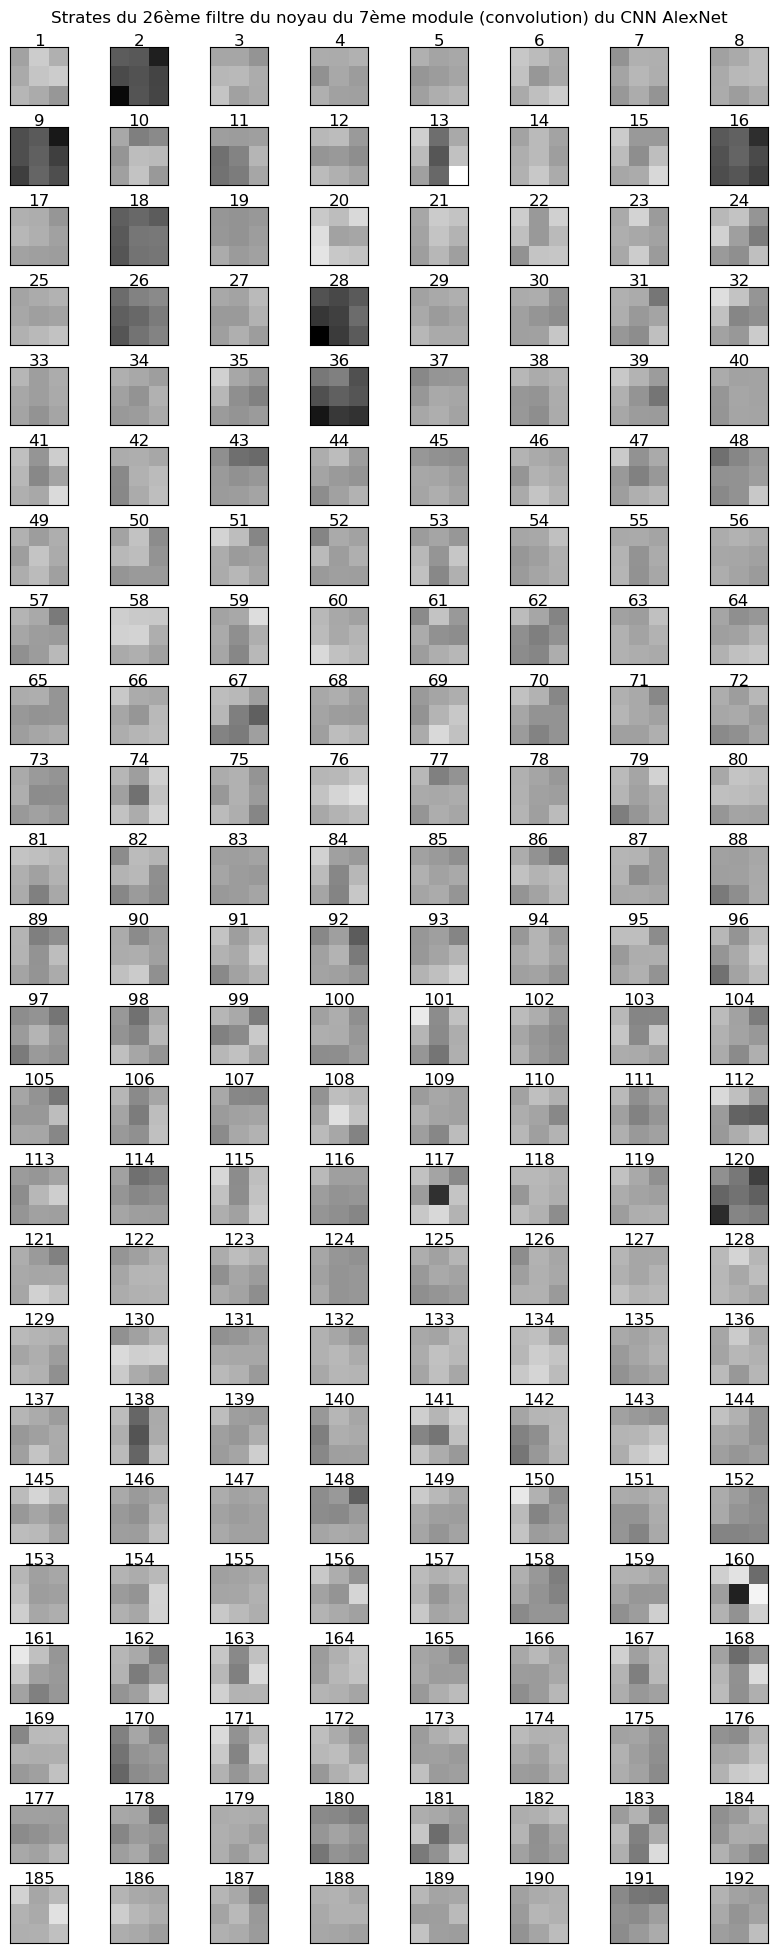

In [12]:
i_module = 6
module = model_convnet_alexnet.features[i_module]
print(module)
filters = module.weight.clone().detach()
print(filters.size())

# Normalization to [0..1], like a RGB picture
for i in range(filters.size(0)):
    filters[i] = (filters[i] - filters[i].min()) / (filters[i].max() - filters[i].min())

per_rows = 8
for idx_filter in [0, 10, 25]:
     # From gray picture to RGB picture
    filter_components = torch.unsqueeze(filters[idx_filter], 1).repeat(1, 3, 1, 1)
    titles=list(range(1, filter_components.size(0) + 1))
    display_images_tensor_grid(
        filter_components,
        per_rows=per_rows,
        suptitle=f"Strates du {idx_filter+1}{i_suffix_fr(idx_filter+1)} filtre du noyau du {i_module+1}{i_suffix_fr(i_module+1)} module (convolution) du CNN AlexNet",
        titles=titles,
        figsize=(8, 20)
        )


#### VGG16

Visualisation des quelques filtres du module de convolution `features[6]` du modèle AlexNet, parmi les 256 appris, chacun d'une taille de 128x3x3, c'est-à-dire composés de 128 strates de taille 3x3.

Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([256, 128, 3, 3])


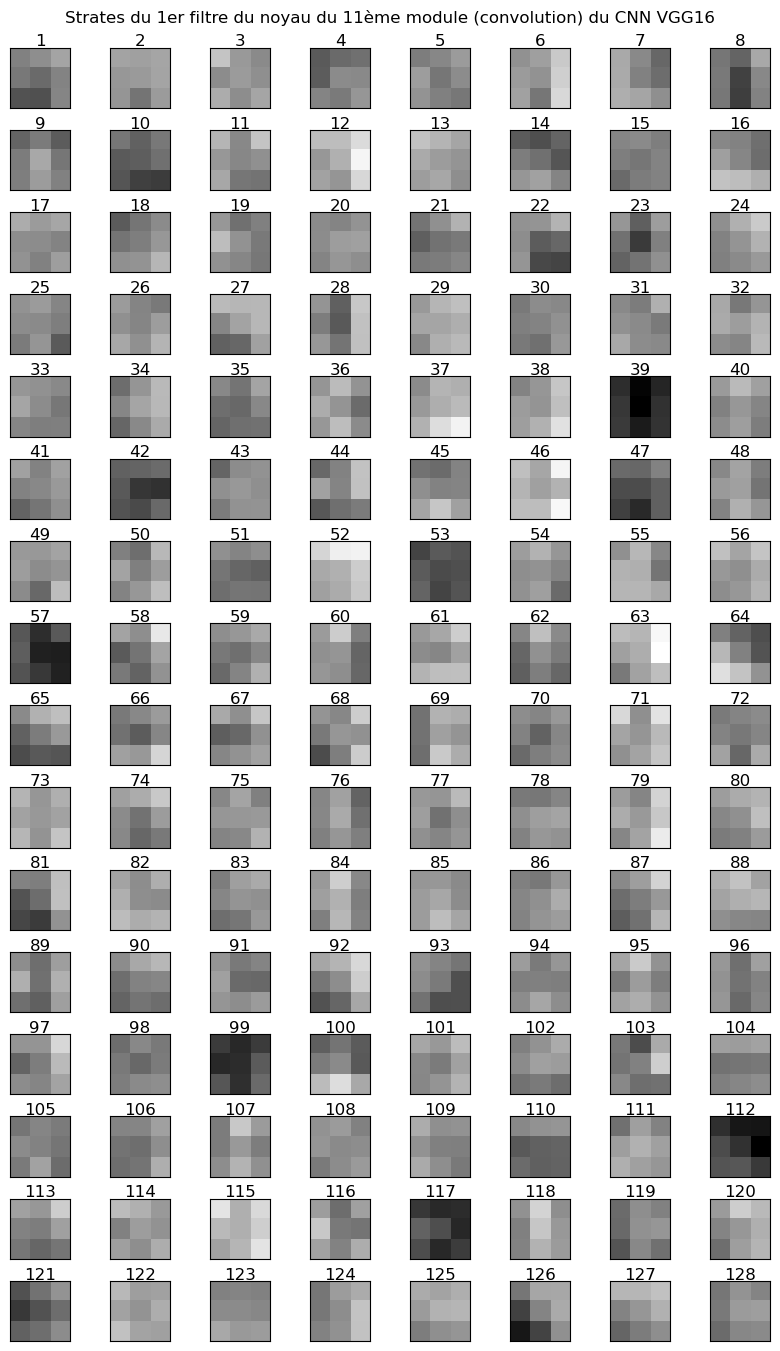

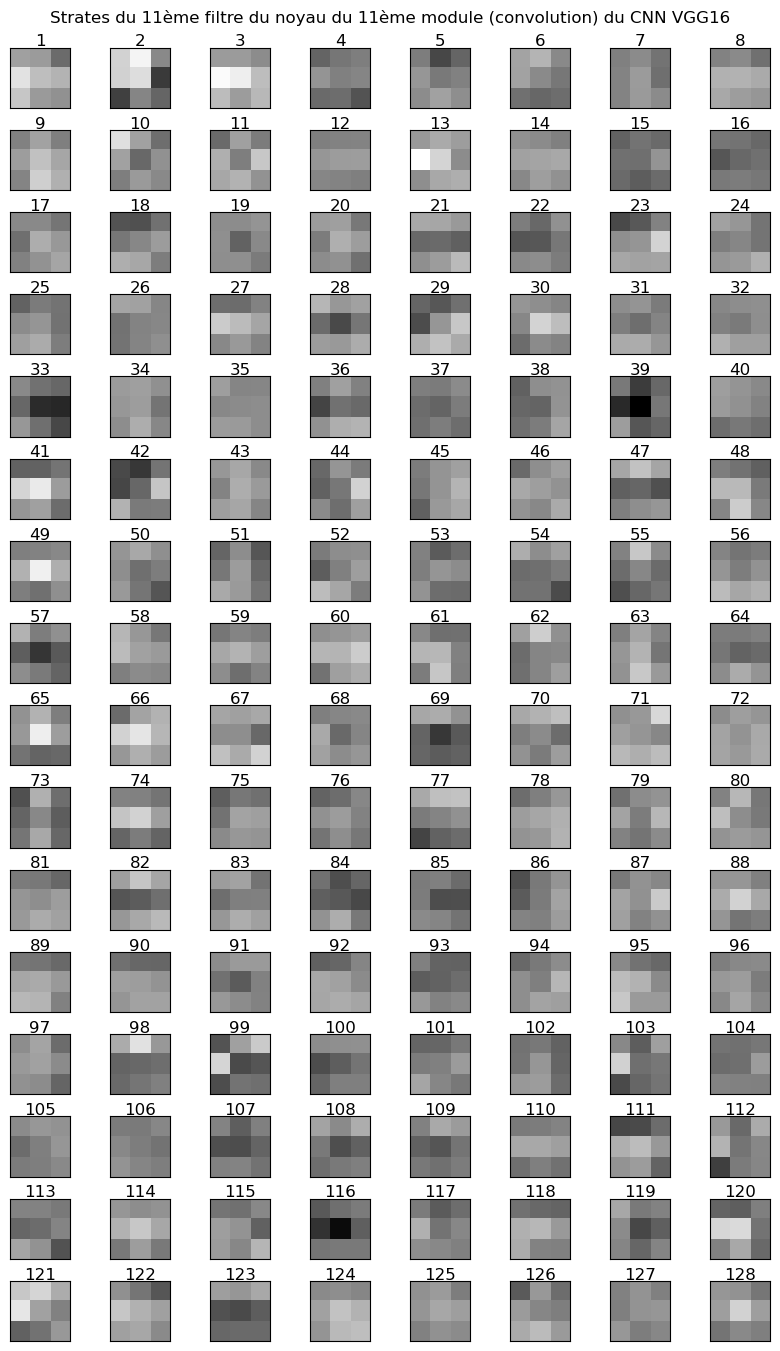

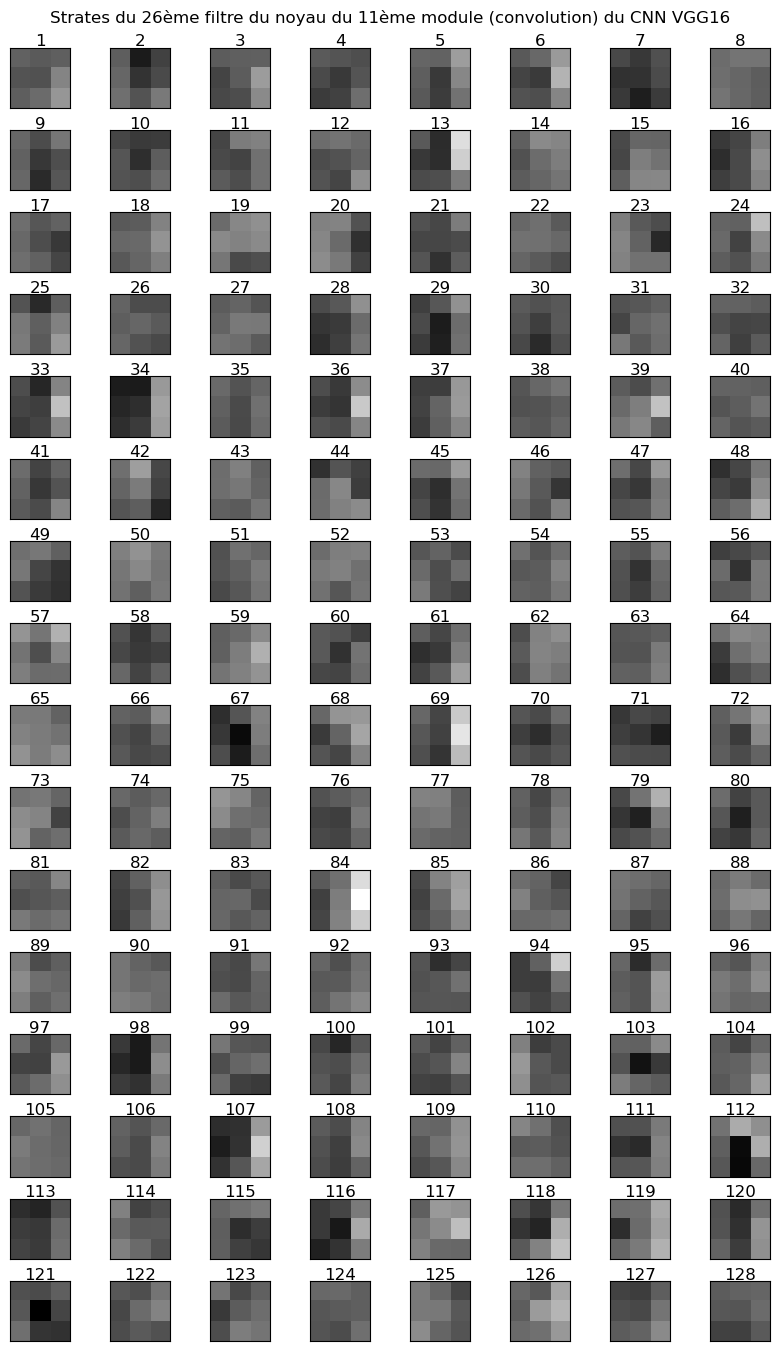

In [13]:
i_module = 10
module = model_convnet_vgg16.features[i_module]
print(module)
filters = module.weight.clone().detach()
print(filters.size())

# Normalization to [0..1], like a RGB picture
for i in range(filters.size(0)):
    filters[i] = (filters[i] - filters[i].min()) / (filters[i].max() - filters[i].min())

per_rows = 8
for idx_filter in [0, 10, 25]:
     # From gray picture to RGB picture
    filter_components = torch.unsqueeze(filters[idx_filter], 1).repeat(1, 3, 1, 1)
    titles=list(range(1, filter_components.size(0) + 1))
    display_images_tensor_grid(
        filter_components,
        per_rows=per_rows,
        suptitle=f"Strates du {idx_filter+1}{i_suffix_fr(idx_filter+1)} filtre du noyau du {i_module+1}{i_suffix_fr(i_module+1)} module (convolution) du CNN VGG16",
        titles=titles,
        figsize=(8, 14)
        )

## Affichage direct des cartes de caractéristiques

### De la couche couche cachée en sortie du premier bloc de convolution

#### AlexNet

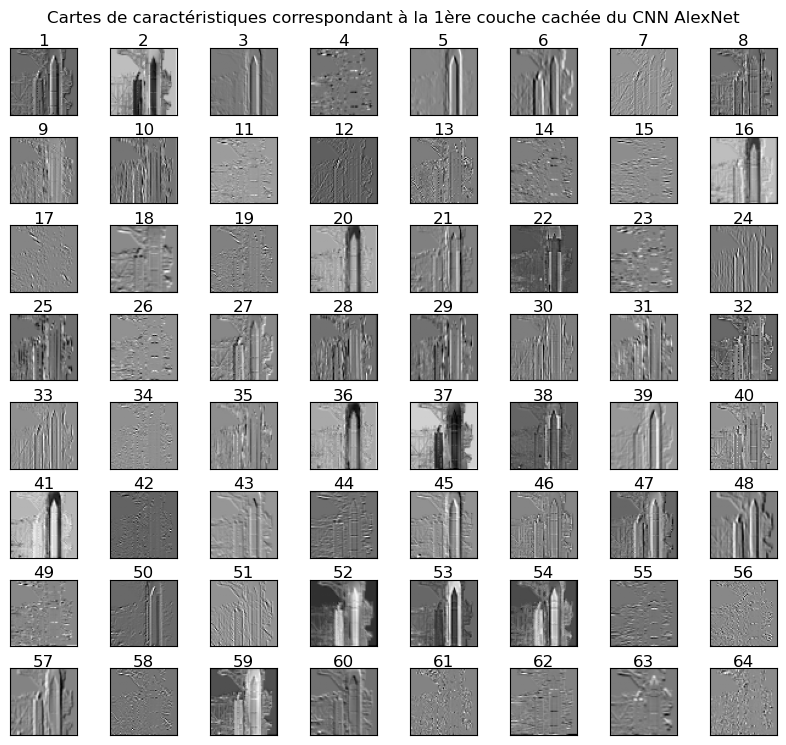

In [14]:
idx_layer = 0
img_trfm = transforms_for_alexnet(img)
output = model_for_deconv_alexnet.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3))),
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"Cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, False)} couche cachée du CNN AlexNet",
    figsize=(8, 8)
    )

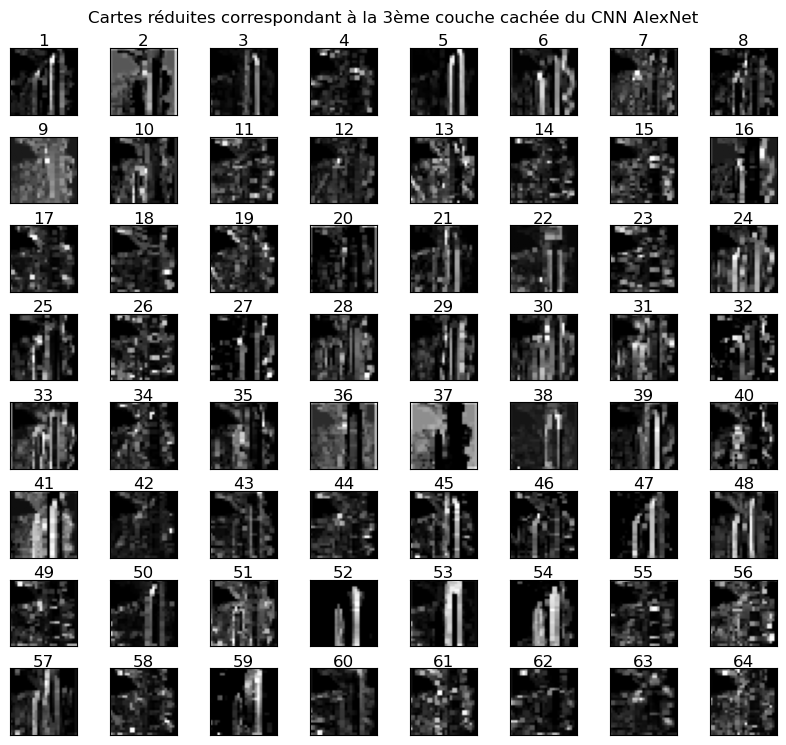

In [15]:
idx_layer = 2
img_trfm = transforms_for_alexnet(img)
output = model_for_deconv_alexnet.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3))),
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"Cartes réduites correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, False)} couche cachée du CNN AlexNet",
    figsize=(8, 8)
    )

#### VGG16

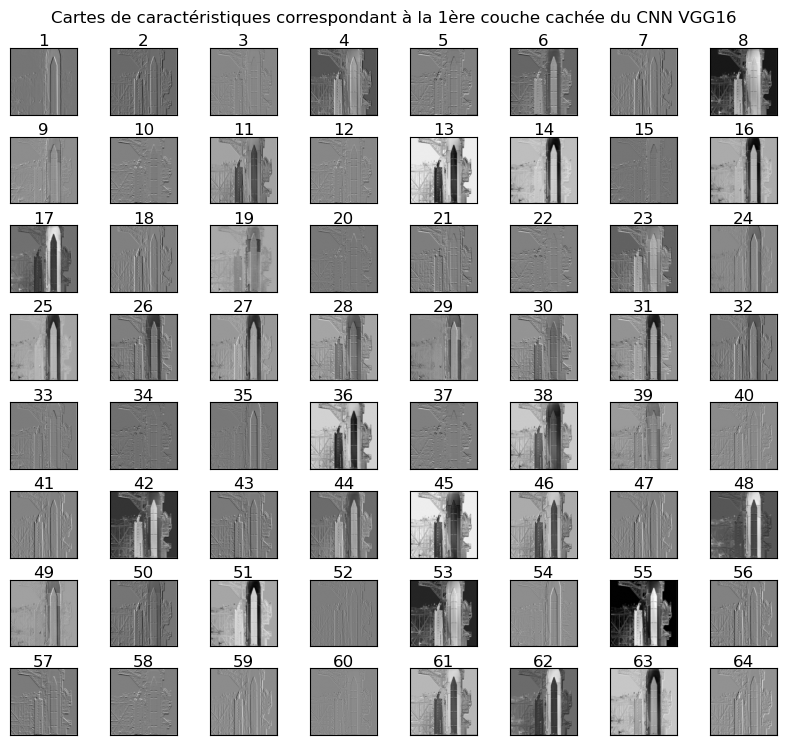

In [16]:
idx_layer = 0
img_trfm = transforms_for_vgg16(img)
output = model_for_deconv_vgg16.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3))),
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"Cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, False)} couche cachée du CNN VGG16",
    figsize=(8, 8)
    )

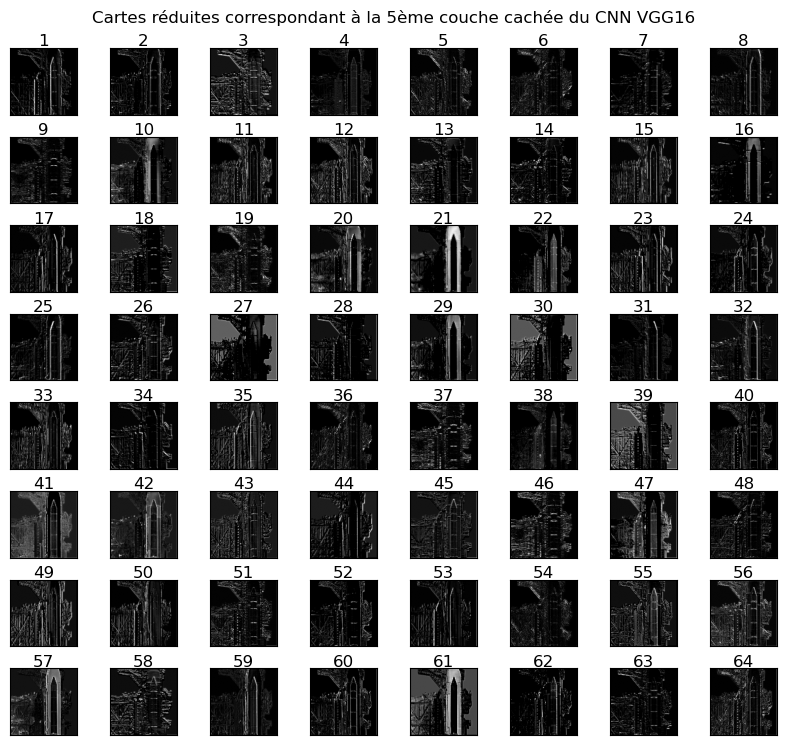

In [17]:
idx_layer = 4
img_trfm = transforms_for_vgg16(img)
output = model_for_deconv_vgg16.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3))),
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"Cartes réduites correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, False)} couche cachée du CNN VGG16",
    figsize=(8, 8)
    )

### D'une couche cachée de profondeur intermédiaire

#### Alexnet

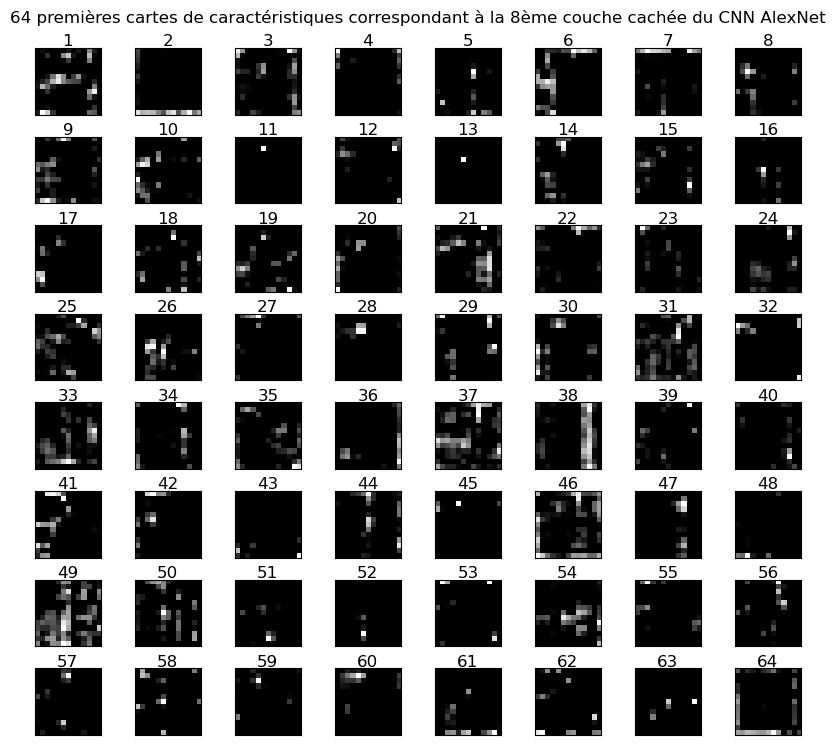

In [18]:
idx_layer = 7
img_trfm = transforms_for_alexnet(img)
output = model_for_deconv_alexnet.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3)))[:64, :, :, :],
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"64 premières cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, False)} couche cachée du CNN AlexNet",
    figsize=(8, 8)
    )

#### VGA16

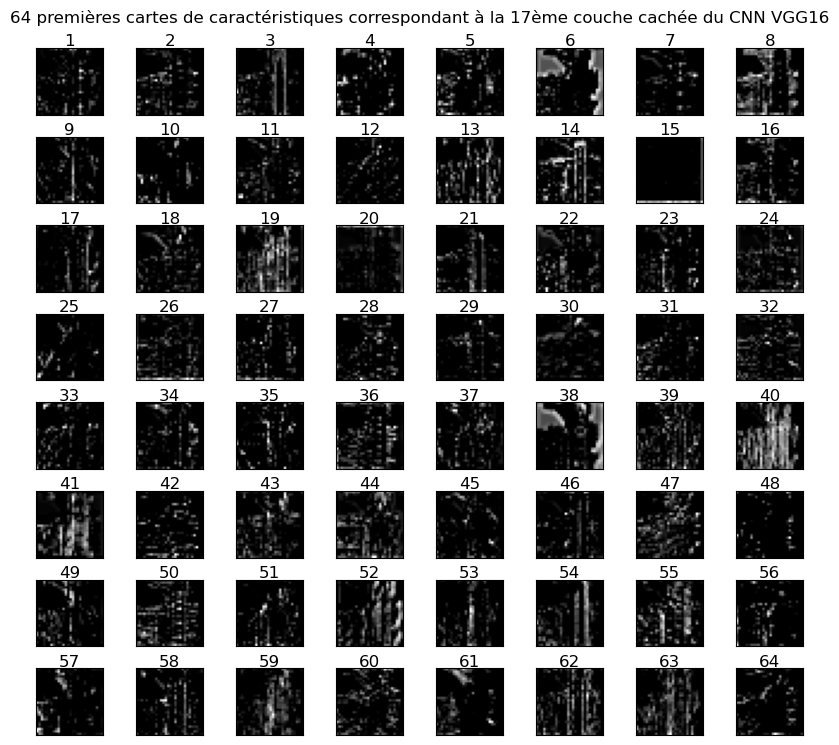

In [19]:
idx_layer = 16
img_trfm = transforms_for_vgg16(img)
output = model_for_deconv_vgg16.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3)))[:64, :, :, :],
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"64 premières cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, True)} couche cachée du CNN VGG16",
    figsize=(8, 8)
    )

### De la couche cachée en sortie du dernier bloc de convolution

#### AlexNet

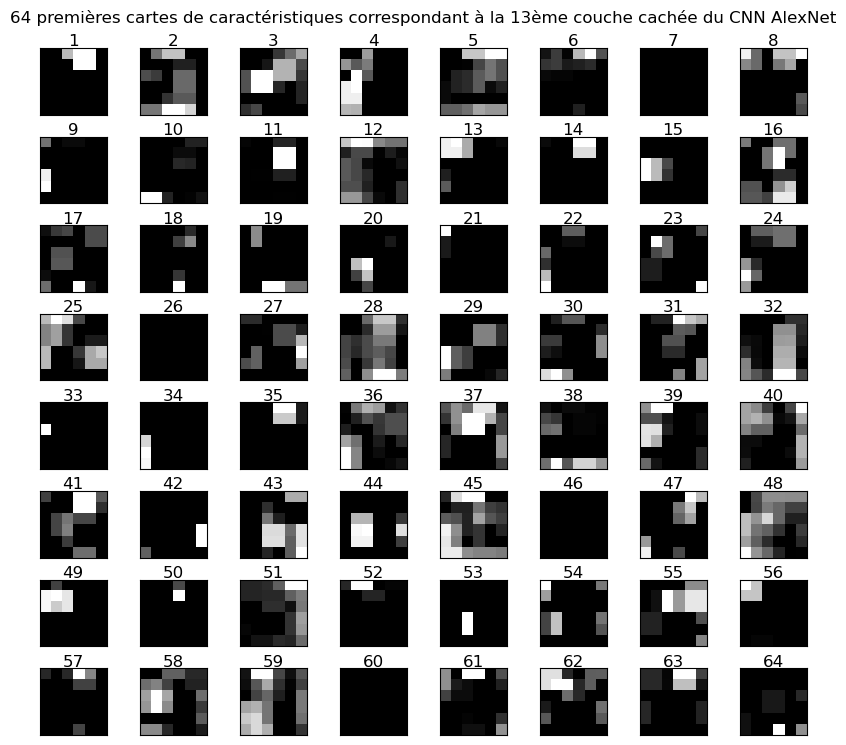

In [20]:
idx_layer = 12
img_trfm = transforms_for_alexnet(img)
output = model_for_deconv_alexnet.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3)))[:64, :, :, :],
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"64 premières cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, True)} couche cachée du CNN AlexNet",
    figsize=(8, 8)
    )

#### VGA16

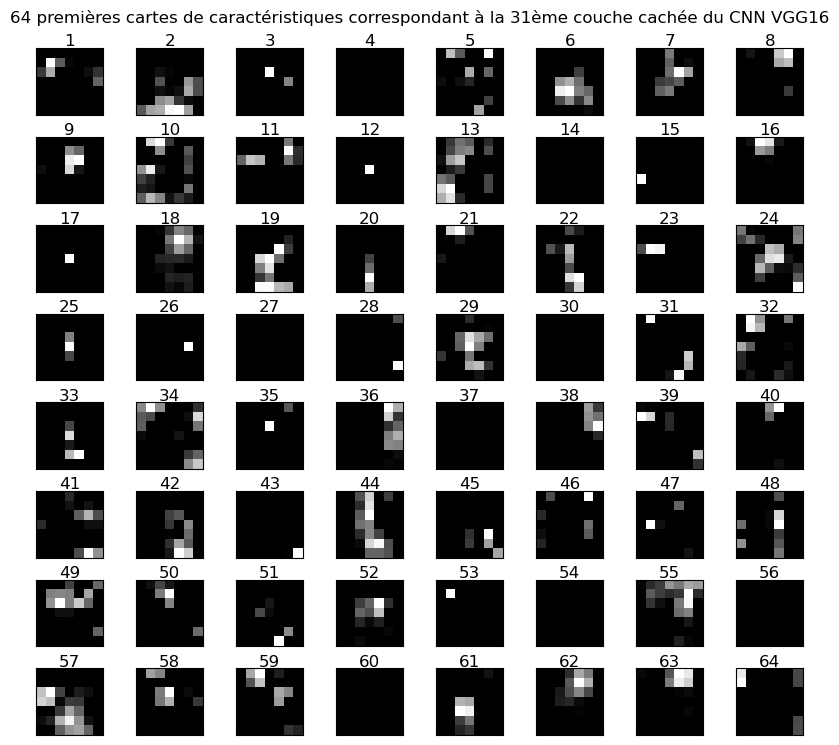

In [21]:
idx_layer = 30
img_trfm = transforms_for_vgg16(img)
output = model_for_deconv_vgg16.forward_for_deconv(img_trfm.unsqueeze(0), idx_layer, return_switch_indices=False).detach()

display_images_tensor_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3)))[:64, :, :, :],
    per_rows=8,
    titles=range(1, output.size(1)+1),
    suptitle=f"64 premières cartes de caractéristiques correspondant à la {idx_layer+1}{i_suffix_fr(idx_layer+1, True)} couche cachée du CNN VGG16",
    figsize=(8, 8)
    )